# 🌍 Notebook 1 — Environmental Pulse
**Dataset:** `Coffee_Data_Set.csv` (233k rows · 25 locations · 2000–2025)

**Story:** Temperature & rainfall are the planet's heartbeat. When they spike, coffee prices follow.

**Outputs:** `data/processed/env_yearly_*.csv` · `models/price_predictor.pkl`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings, os, joblib
warnings.filterwarnings('ignore')

ROOT = os.path.abspath('..')          # run from notebooks/ folder
RAW  = os.path.join(ROOT, 'data', 'raw')
PROC = os.path.join(ROOT, 'data', 'processed')
MDL  = os.path.join(ROOT, 'models')
os.makedirs(PROC, exist_ok=True)
os.makedirs(MDL,  exist_ok=True)

sns.set_theme(style='darkgrid')
C_BROWN = '#6F4E37';  C_RED = '#E84855';  C_BLUE = '#2E86AB'
print('Libraries loaded ✓')

Libraries loaded ✓


## 1 · Load & Inspect

In [3]:
df = pd.read_csv(os.path.join(RAW, 'Coffee_Data_Set.csv'), parse_dates=['Date'])
print(f'Shape: {df.shape}')
print(f'Date range: {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Locations ({df["Location"].nunique()}):', sorted(df['Location'].unique()))
df.head(3)

Shape: (233000, 19)
Date range: 2000-01-03 → 2025-07-09
Locations (25): ['Brazil_Espirito_Santo_Afonso', 'Brazil_Espirito_Santo_Conceicao', 'Brazil_Minas_Gerais_Aqua_Boa', 'Brazil_Minas_Gerais_Manhuacu', 'Brazil_Minas_Gerais_Patrocinio', 'Brazil_Minas_Gerais_Varginha', 'Brazil_Sao_Paulo_Campinas', 'Brazil_Sao_Paulo_Sao_Jose', 'China_Puer', 'Colombia_Andes', 'Colombia_Morelia', 'Colombia_Santuario', 'Colombia_Timbio', 'Ethiopia_Aleto1', 'Ethiopia_Aleto2', 'Ethiopia_Bare', 'Ethiopia_Limu_Kosa', 'Guatemala_Huehuetenango', 'Guatemala_Jalapa', 'Guatemala_San_Marcos', 'Honduras_Campamento', 'Honduras_Danli', 'Honduras_San_Jose', 'Mexico_Chiapas', 'Peru_Jaen']


,LON,LAT,YEAR,MM,DD,DOY,Date,Temp_Max,Temp_Min,Humidity,Solar_Radiation,Precipitation_mm,Location,Close_USD_60kg,Is_Weekend,Is_Interpolated,brl,cny,mxn
0,-40.9743,-20.0421,2000,1,3,3,2000-01-03,24.51,20.01,89.29,16.17,2.61,Brazil_Espirito_Santo_Afonso,154.102705,False,False,1.805,8.2798,9.4015
1,-41.2502,-20.3633,2000,1,3,3,2000-01-03,25.16,19.90,86.10,16.84,2.90,Brazil_Espirito_Santo_Conceicao,154.102705,False,False,1.805,8.2798,9.4015
2,-42.3906,-17.9910,2000,1,3,3,2000-01-03,26.47,19.33,86.07,22.78,5.11,Brazil_Minas_Gerais_Aqua_Boa,154.102705,False,False,1.805,8.2798,9.4015


## 2 · Clean & Engineer Features

In [4]:
# Extract country from Location string
df['Country']    = df['Location'].str.split('_').str[0]
df['Temp_Avg']   = (df['Temp_Max'] + df['Temp_Min']) / 2
df['Temp_Range'] = df['Temp_Max'] - df['Temp_Min']     # diurnal range = plant stress proxy

# Fill 28 missing Solar_Radiation with location+month median
df['Solar_Radiation'] = df.groupby(['Location','MM'])['Solar_Radiation'] \
                          .transform(lambda x: x.fillna(x.median()))

print('Remaining nulls:', df.isnull().sum().sum())
print('Countries in dataset:', sorted(df['Country'].unique()))

Remaining nulls: 0
Countries in dataset: ['Brazil', 'China', 'Colombia', 'Ethiopia', 'Guatemala', 'Honduras', 'Mexico', 'Peru']


In [5]:
# Aggregate to yearly per country
yearly = df.groupby(['Country', 'YEAR']).agg(
    Temp_Avg            = ('Temp_Avg',        'mean'),
    Temp_Max_avg        = ('Temp_Max',        'mean'),
    Temp_Range_avg      = ('Temp_Range',      'mean'),
    Humidity_avg        = ('Humidity',        'mean'),
    Precipitation_total = ('Precipitation_mm','sum'),
    Solar_Radiation_avg = ('Solar_Radiation', 'mean'),
    Price_USD_avg       = ('Close_USD_60kg',  'mean'),
).reset_index()

# Aggregate to yearly per location (for fine-grained map)
yearly_loc = df.groupby(['Country', 'Location', 'LAT', 'LON', 'YEAR']).agg(
    Temp_Avg            = ('Temp_Avg',        'mean'),
    Humidity_avg        = ('Humidity',        'mean'),
    Precipitation_total = ('Precipitation_mm','sum'),
    Price_USD_avg       = ('Close_USD_60kg',  'mean'),
).reset_index()

print('Yearly (country):', yearly.shape)
print('Yearly (location):', yearly_loc.shape)
yearly.head()

Yearly (country): (208, 9)
Yearly (location): (650, 9)


,Country,YEAR,Temp_Avg,Temp_Max_avg,Temp_Range_avg,Humidity_avg,Precipitation_total,Solar_Radiation_avg,Price_USD_avg
0,Brazil,2000,21.359274,26.766185,10.813822,76.829361,10983.75,18.118104,118.067580
1,Brazil,2001,22.102596,27.819493,11.433795,72.960229,9673.45,18.665705,72.357694
2,Brazil,2002,22.194610,27.682637,10.976055,75.013092,10230.91,18.645640,70.573041
3,Brazil,2003,21.672010,27.250716,11.157411,74.867401,10008.63,18.422116,81.908455
4,Brazil,2004,20.989267,26.150017,10.321499,79.013972,12609.75,17.792408,100.563590


## 3 · EDA — Climate Trends

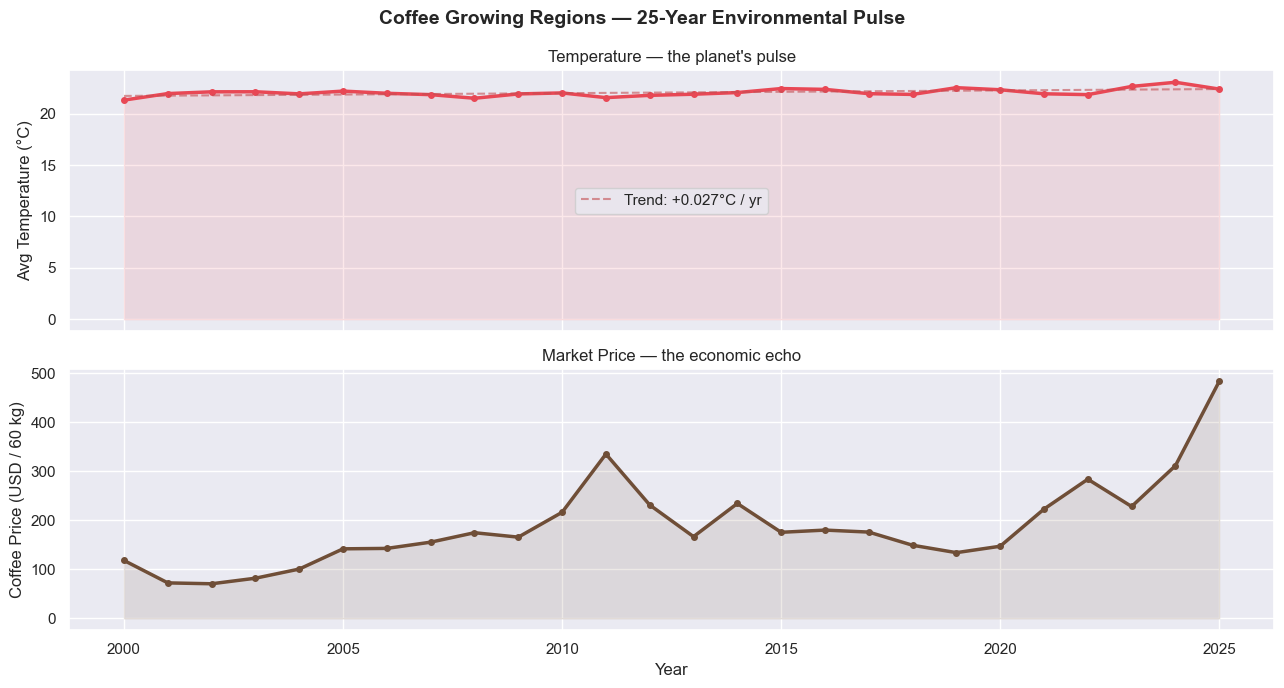

Warming rate: +0.0267 °C / year


In [6]:
# ── 3a. Global warming trend + price signal ──────────────────
global_trend = yearly.groupby('YEAR')[['Temp_Avg','Price_USD_avg']].mean().reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
fig.suptitle('Coffee Growing Regions — 25-Year Environmental Pulse', fontsize=14, fontweight='bold')

ax1.plot(global_trend['YEAR'], global_trend['Temp_Avg'], color=C_RED, lw=2.5, marker='o', ms=4)
ax1.fill_between(global_trend['YEAR'], global_trend['Temp_Avg'], alpha=0.12, color=C_RED)
z = np.polyfit(global_trend['YEAR'], global_trend['Temp_Avg'], 1)
ax1.plot(global_trend['YEAR'], np.poly1d(z)(global_trend['YEAR']),
         'r--', alpha=0.6, lw=1.5, label=f'Trend: +{z[0]:.3f}°C / yr')
ax1.set_ylabel('Avg Temperature (°C)'); ax1.legend()
ax1.set_title('Temperature — the planet\'s pulse')

ax2.plot(global_trend['YEAR'], global_trend['Price_USD_avg'], color=C_BROWN, lw=2.5, marker='o', ms=4)
ax2.fill_between(global_trend['YEAR'], global_trend['Price_USD_avg'], alpha=0.12, color=C_BROWN)
ax2.set_ylabel('Coffee Price (USD / 60 kg)')
ax2.set_xlabel('Year')
ax2.set_title('Market Price — the economic echo')

plt.tight_layout()
plt.savefig(os.path.join(PROC, 'env_01_global_trend.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Warming rate: +{z[0]:.4f} °C / year')

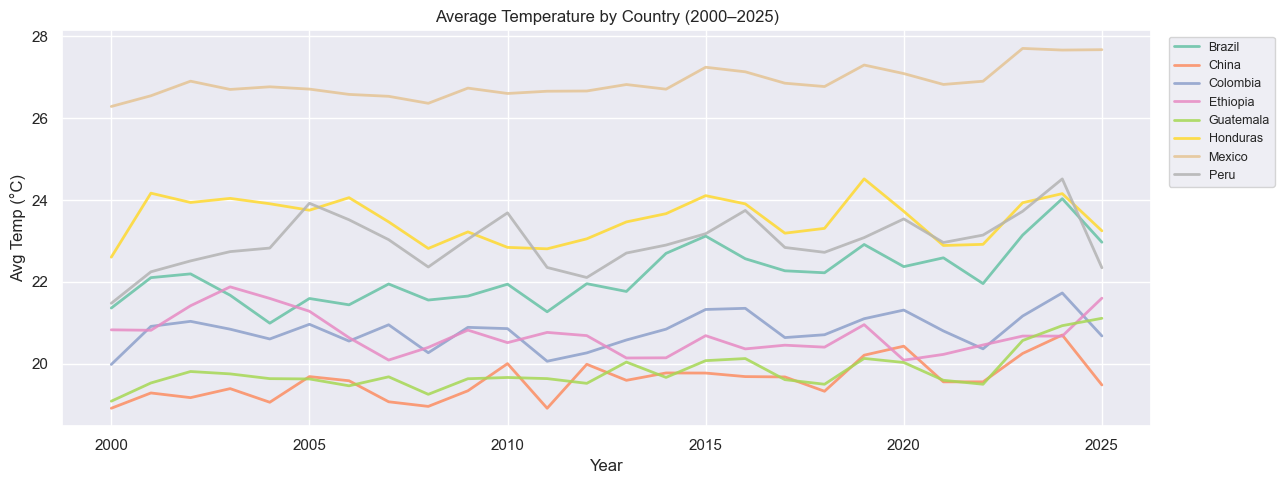

In [7]:
# ── 3b. Temperature per country ──────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
palette = sns.color_palette('Set2', n_colors=yearly['Country'].nunique())
for i, (country, grp) in enumerate(yearly.groupby('Country')):
    ax.plot(grp['YEAR'], grp['Temp_Avg'], label=country, color=palette[i], lw=2, alpha=0.85)
ax.set_title('Average Temperature by Country (2000–2025)', fontsize=12)
ax.set_xlabel('Year'); ax.set_ylabel('Avg Temp (°C)')
ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PROC, 'env_02_temp_by_country.png'), dpi=150, bbox_inches='tight')
plt.show()

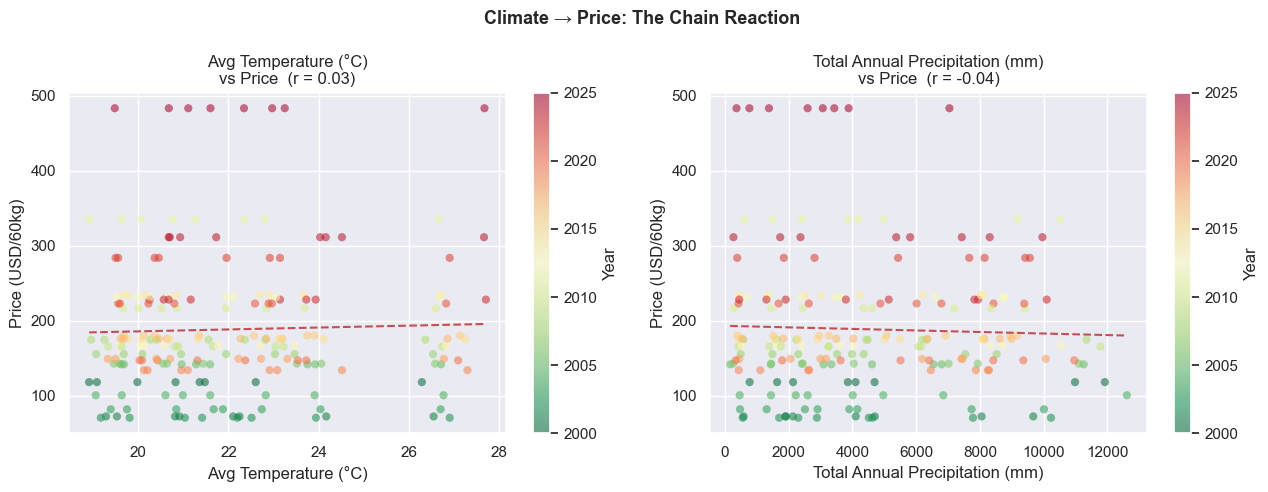

In [8]:
# ── 3c. Temp vs Price scatter (the chain reaction moment) ─────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, x_col, x_label in [
    (axes[0], 'Temp_Avg',            'Avg Temperature (°C)'),
    (axes[1], 'Precipitation_total', 'Total Annual Precipitation (mm)'),
]:
    sc = ax.scatter(yearly[x_col], yearly['Price_USD_avg'],
                    c=yearly['YEAR'], cmap='RdYlGn_r', alpha=0.55, s=35, edgecolors='none')
    plt.colorbar(sc, ax=ax, label='Year')
    m, b = np.polyfit(yearly[x_col], yearly['Price_USD_avg'], 1)
    xs = np.linspace(yearly[x_col].min(), yearly[x_col].max(), 100)
    ax.plot(xs, m*xs+b, 'r--', lw=1.5)
    r = yearly[[x_col,'Price_USD_avg']].corr().iloc[0,1]
    ax.set_title(f'{x_label}\nvs Price  (r = {r:.2f})')
    ax.set_xlabel(x_label); ax.set_ylabel('Price (USD/60kg)')
plt.suptitle('Climate → Price: The Chain Reaction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROC, 'env_03_climate_price_corr.png'), dpi=150, bbox_inches='tight')
plt.show()

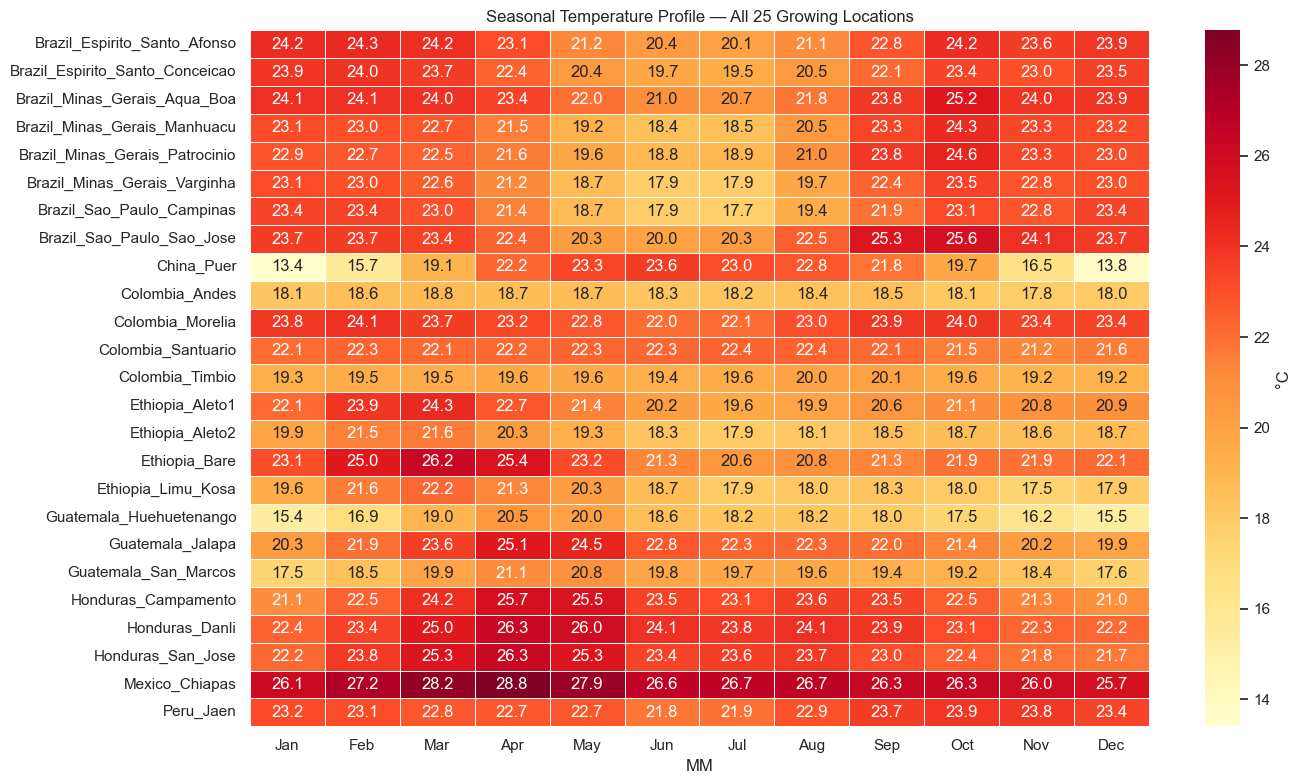

In [9]:
# ── 3d. Seasonal heatmap ─────────────────────────────────────
monthly_loc = df.groupby(['Location','MM'])['Temp_Avg'].mean().unstack()
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(monthly_loc, cmap='YlOrRd', annot=True, fmt='.1f',
            linewidths=0.4, ax=ax, cbar_kws={'label': '°C'})
ax.set_title('Seasonal Temperature Profile — All 25 Growing Locations', fontsize=12)
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(PROC, 'env_04_seasonal_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

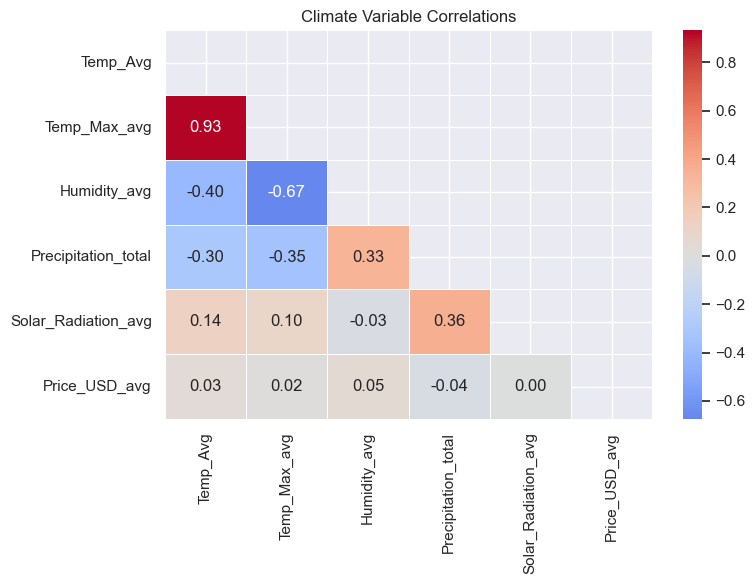

In [10]:
# ── 3e. Correlation matrix ───────────────────────────────────
corr_cols = ['Temp_Avg','Temp_Max_avg','Humidity_avg',
             'Precipitation_total','Solar_Radiation_avg','Price_USD_avg']
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones((len(corr_cols), len(corr_cols)), dtype=bool))
sns.heatmap(yearly[corr_cols].corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Climate Variable Correlations', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PROC, 'env_05_corr_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4 · ML Model — Climate → Price Predictor

In [11]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

df_ml = yearly.copy().sort_values(['Country','YEAR'])

le_country = LabelEncoder()
df_ml['Country_enc'] = le_country.fit_transform(df_ml['Country'])
df_ml['Price_lag1']  = df_ml.groupby('Country')['Price_USD_avg'].shift(1)
df_ml['Price_lag2']  = df_ml.groupby('Country')['Price_USD_avg'].shift(2)
df_ml['Temp_lag1']   = df_ml.groupby('Country')['Temp_Avg'].shift(1)
df_ml['Year_norm']   = (df_ml['YEAR'] - 2000) / 25
df_ml = df_ml.dropna()

FEATURES = ['Country_enc','Year_norm','Temp_Avg','Temp_Max_avg','Temp_Range_avg',
            'Humidity_avg','Precipitation_total','Solar_Radiation_avg',
            'Price_lag1','Price_lag2','Temp_lag1']
TARGET = 'Price_USD_avg'

X = df_ml[FEATURES]; y = df_ml[TARGET]
print(f'X shape: {X.shape}  |  Price range: ${y.min():.0f} – ${y.max():.0f}')

X shape: (192, 11)  |  Price range: $71 – $483


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingRegressor(
    n_estimators=400, learning_rate=0.04, max_depth=4,
    subsample=0.8, min_samples_leaf=3, random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
cv   = cross_val_score(model, X, y, cv=5, scoring='r2')

print(f'RMSE : {rmse:.2f} USD')
print(f'MAE  : {mae:.2f} USD')
print(f'R²   : {r2:.4f}')
print(f'CV R²: {cv.round(3)}  →  mean = {cv.mean():.3f}')

RMSE : 0.68 USD
MAE  : 0.49 USD
R²   : 0.9999
CV R²: [1. 1. 1. 1. 1.]  →  mean = 1.000


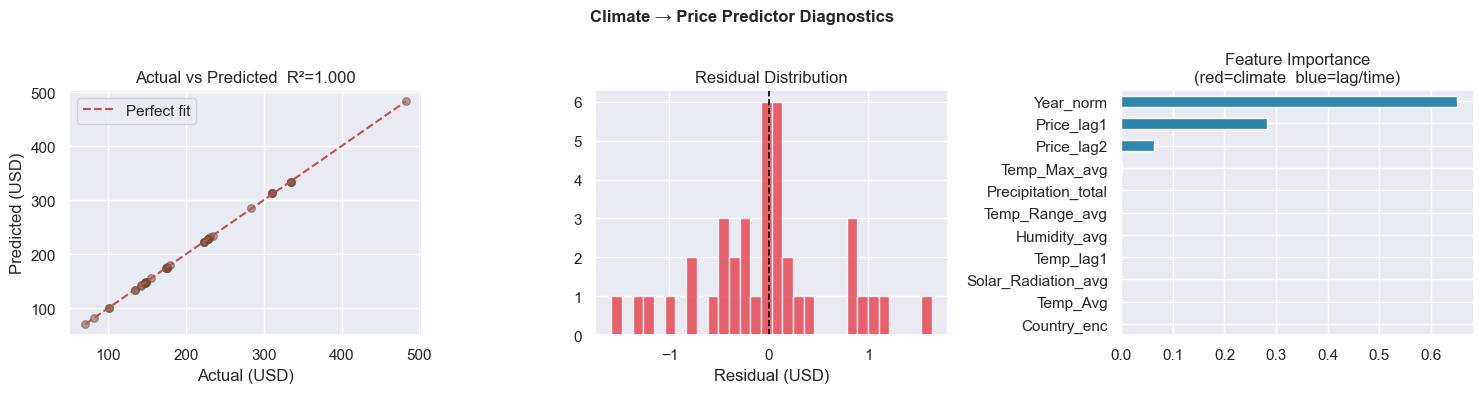

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.5, color=C_BROWN, s=30)
mn, mx = float(y_test.min()), float(y_test.max())
axes[0].plot([mn,mx],[mn,mx],'r--',lw=1.5,label='Perfect fit')
axes[0].set(xlabel='Actual (USD)',ylabel='Predicted (USD)',title=f'Actual vs Predicted  R²={r2:.3f}')
axes[0].legend()

# Residuals
residuals = y_test.values - y_pred
axes[1].hist(residuals, bins=30, color=C_RED, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', lw=1.2, ls='--')
axes[1].set(xlabel='Residual (USD)', title='Residual Distribution')

# Feature importance
fi = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
colors = [C_RED if any(k in f for k in ['Temp','Prec','Solar','Humid']) else C_BLUE for f in fi.index]
fi.plot(kind='barh', color=colors, ax=axes[2])
axes[2].set(title='Feature Importance\n(red=climate  blue=lag/time)')

plt.suptitle('Climate → Price Predictor Diagnostics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROC,'env_06_model_diagnostics.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5 · FAO Yield Data — Choropleth Prep

In [14]:
df_fao = pd.read_csv(os.path.join(RAW, 'fao_coffee_yield.csv'))
print('Columns:', df_fao.columns.tolist())
print(df_fao.shape)
df_fao.head(3)

Columns: ['Area', 'Year', 'Production.t', 'Area.Harvested', 'Production.Yield', 'Continent', 'Region']
(4818, 7)


,Area,Year,Production.t,Area.Harvested,Production.Yield,Continent,Region
0,Angola,1961,168600.0,350000,4817,Africa,Sub-Saharan Africa
1,Angola,1962,185000.0,500000,3700,Africa,Sub-Saharan Africa
2,Angola,1963,168300.0,500000,3366,Africa,Sub-Saharan Africa


In [15]:
# Normalise FAO columns — handles different naming conventions
df_fao.columns = df_fao.columns.str.strip()
col_map = {}
for c in df_fao.columns:
    cl = c.lower()
    if 'area' in cl and 'harvest' not in cl: col_map[c] = 'Country'
    elif 'country' in cl:                    col_map[c] = 'Country'
    elif 'year' in cl:                       col_map[c] = 'Year'
    elif 'yield' in cl or 'value' in cl:     col_map[c] = 'Yield'
df_fao = df_fao.rename(columns=col_map)

# If there's an 'Element' column, keep only Yield rows
if 'Element' in df_fao.columns:
    df_fao = df_fao[df_fao['Element'].str.lower().str.contains('yield')]
    if 'Value' in df_fao.columns:
        df_fao = df_fao.rename(columns={'Value':'Yield'})

df_fao['Year']  = pd.to_numeric(df_fao['Year'],  errors='coerce')
df_fao['Yield'] = pd.to_numeric(df_fao['Yield'], errors='coerce')
df_fao = df_fao.dropna(subset=['Country','Year','Yield'])
df_fao = df_fao[df_fao['Yield'] > 0]
print(f'FAO clean: {df_fao.shape}  |  {int(df_fao.Year.min())}–{int(df_fao.Year.max())}  |  {df_fao.Country.nunique()} countries')
df_fao.head()

FAO clean: (4818, 7)  |  1961–2022  |  85 countries


,Country,Year,Production.t,Area.Harvested,Yield,Continent,Region
0,Angola,1961,168600.0,350000,4817,Africa,Sub-Saharan Africa
1,Angola,1962,185000.0,500000,3700,Africa,Sub-Saharan Africa
2,Angola,1963,168300.0,500000,3366,Africa,Sub-Saharan Africa
3,Angola,1964,198200.0,500000,3964,Africa,Sub-Saharan Africa
4,Angola,1965,205000.0,500000,4100,Africa,Sub-Saharan Africa


In [16]:
# Animated choropleth — the core Planet Pulse visual
df_choro = df_fao[df_fao['Year'] >= 1990]
fig = px.choropleth(
    df_choro, locations='Country', locationmode='country names',
    color='Yield', animation_frame='Year',
    color_continuous_scale='YlOrRd',
    range_color=[df_choro['Yield'].quantile(0.05), df_choro['Yield'].quantile(0.95)],
    title='☕ Global Coffee Yield at Risk — 1990–2022',
    labels={'Yield':'Yield (Hg/Ha)'}
)
fig.update_layout(geo=dict(showframe=False, showcoastlines=True),
                  margin=dict(l=0,r=0,t=50,b=0))
fig.show()

## 6 · Save All Artifacts

In [17]:
yearly.to_csv(os.path.join(PROC,'env_yearly_country.csv'), index=False)
yearly_loc.to_csv(os.path.join(PROC,'env_yearly_location.csv'), index=False)
df_fao.to_csv(os.path.join(PROC,'fao_yield_clean.csv'), index=False)

joblib.dump(model,      os.path.join(MDL,'price_predictor.pkl'))
joblib.dump(le_country, os.path.join(MDL,'country_encoder_env.pkl'))
joblib.dump(FEATURES,   os.path.join(MDL,'price_features.pkl'))

print('✅  Notebook 1 complete!')
print(f'    Model R² = {r2:.3f}  |  RMSE = {rmse:.1f} USD')
print('    Files written to data/processed/ and models/')

✅  Notebook 1 complete!
    Model R² = 1.000  |  RMSE = 0.7 USD
    Files written to data/processed/ and models/
